# Social Media Impact on Teen Mental Health

From: https://www.kaggle.com/datasets/algozee/teenager-menthal-healy?select=Teen_Mental_Health_Dataset.csv

Ziel dieses Datensatzes ist es, Zusammenhänge zwischen den Merkmalen und dem Auftreten von Depressionen zu analysieren sowie ein Modell zu entwickeln, das das Vorliegen einer Depression vorhersagen kann.

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
mental_health = pd.read_csv("Teen_Mental_Health_Dataset.csv")

## Datensatz
### Fehlende Werte

In [20]:
print(mental_health.isna().sum(),"\n")
print(mental_health.duplicated().sum())

age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64 

0


Der Datensatz weist keine Duplikate und fehlende Werte auf, was auf eine guten Datenqualität hindeutet.

### Data Inspection

In [21]:
mental_health.head(15)

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0
5,19,female,7.4,Both,4.4,2.4,2.63,0.6,high,3,5,7,0
6,18,female,2.5,Instagram,6.4,2.4,2.63,0.7,low,2,2,5,0
7,16,male,4.0,Both,4.2,0.5,2.40,1.3,low,6,10,5,0
8,19,female,3.3,TikTok,5.0,2.1,2.04,0.9,high,1,10,9,0
9,15,male,1.9,TikTok,4.9,1.5,3.77,1.1,high,1,1,4,0


In [22]:
mental_health.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   str    
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   str    
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   str    
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), str(3)
memory usage: 122.0 KB


In [23]:
mental_health.describe()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


## EDA


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

| Attribut                      | Skalenniveau  | Datentyp
|-------------------------------|---------------|----------------
| age                           | Verhältnis    | numerisch
| gender                        | Nominal       | kategorisch
| daily_social_media_hours      | Verhältnis    | numerisch
| platform_usage                | Nominal       | kategorisch
| sleep_hours                   | Verhältnis    | numerisch
| screen_time_before_sleep      | Verhältnis    | numerisch
| academic_performance          | Verhältnis    | numerisch
| physical_activity             | Verhältnis    | numerisch
| social_interaction_level      | Ordinal       | kategorisch
| stress_level                  | Ordinal       | numerisch
| anxiety_level                 | Ordinal       | numerisch
| addiction_level               | Ordinal       | numerisch
| depression_label              | Nominal       | kategorisch

### Univariate Analyse

#### Zielvariable

In [25]:
mental_health["depression_label"].value_counts()

depression_label
0    1169
1      31
Name: count, dtype: int64

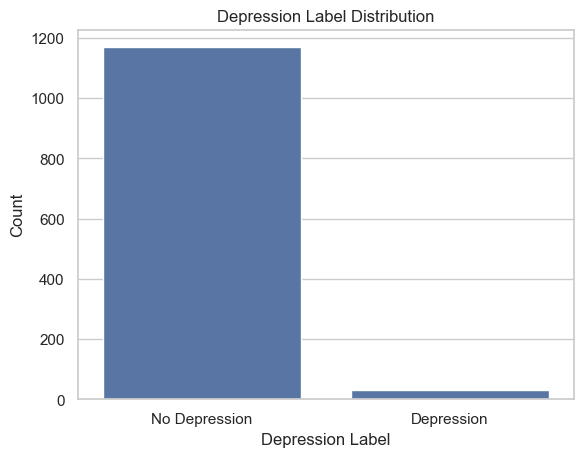

In [26]:
sns.countplot(data=mental_health, x="depression_label")
plt.title("Depression Label Distribution")
plt.xlabel("Depression Label")
plt.ylabel("Count")
plt.xticks([0,1], ["No Depression", "Depression"])
plt.show()

Es liegt eine deutliche Kassenungleichgewichtung vor: Die Klasse *No Depression* ist deutlich häufiger vertreten als die Klasse *Depressionen*. Dies sollte beim Training von Modellen berücksichtigt werden, beispielsweise durch geeignete Evaluationsmetriken oder Verfahren zum Umgang mit unausgeglichenen Klassen.

#### Nummerisch

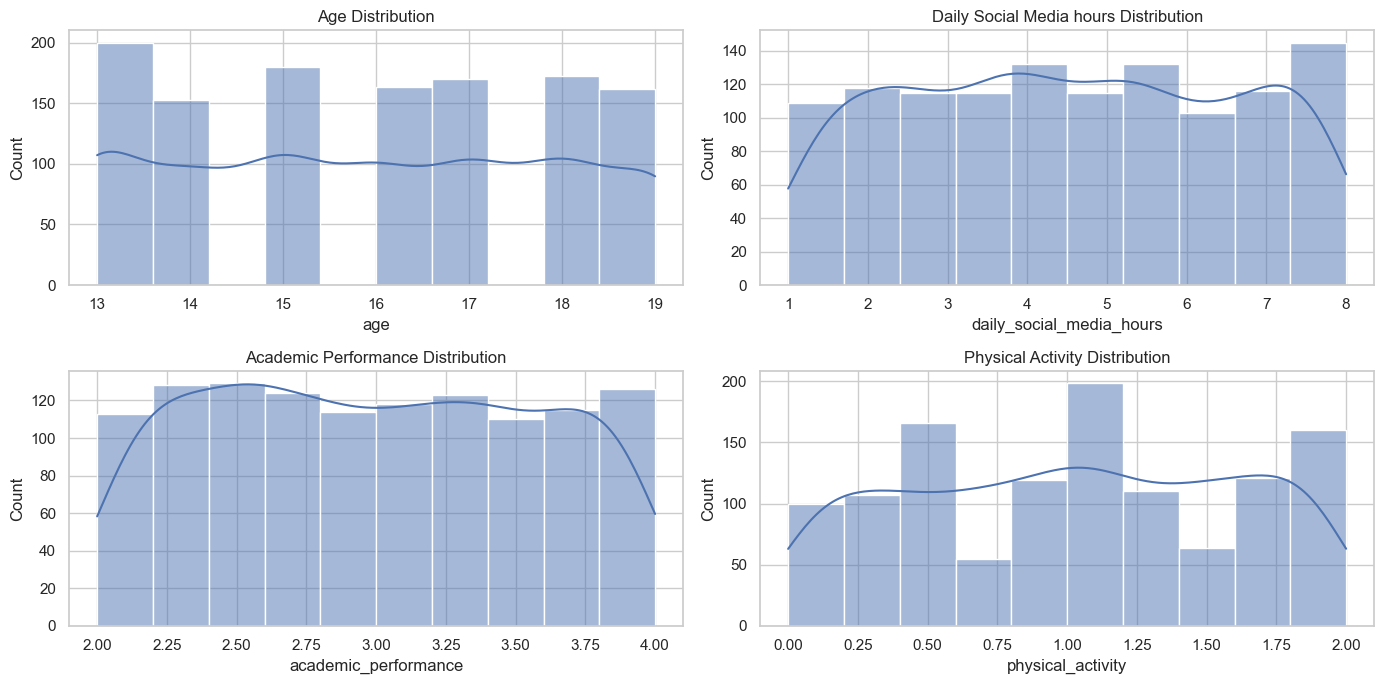

In [27]:
sns.set_theme(style="whitegrid")


fig, axes = plt.subplots(2, 2, figsize=(14, 7))

columns = ["age", "daily_social_media_hours", "academic_performance", "physical_activity"]

titles = ["Age Distribution", "Daily Social Media hours Distribution", "Academic Performance Distribution" , "Physical Activity Distribution"]

for ax, col, title in zip(axes.flatten(), columns, titles):
    sns.histplot(mental_health[col], bins=10, kde=True, ax=ax)
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    
plt.tight_layout()
plt.show()

Die Verteilung von `age`, `daily_social_median_hours` und `academic_performance` wirken vergleichweise gleichmäßig. Auffällige Ausreißer sind in diesen Merkmalen nicht erkennbar.
Zudem zeigt sich, dass einige Jugendliche sehr hohe Nutzerzeiten sozialer Medien von bis zu acht Stunden pro Tag aufweisen. Ein direkter Zusammenhang zwischen hoher Bildschirmzeit und geringer körperlicher Aktivität aus der univarianten Analyse jedoch noch nicht eindeutig abgeleitet werden.

##### Sleep

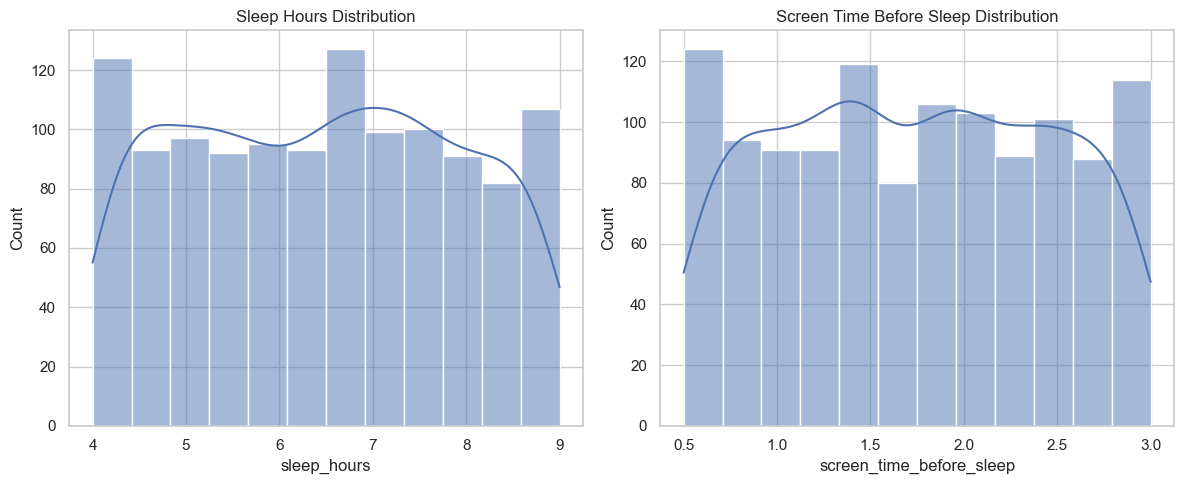

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

columns = ["sleep_hours", "screen_time_before_sleep"]

titles = ["Sleep Hours Distribution", "Screen Time Before Sleep Distribution"]

for ax, col, title in zip(axes.flatten(), columns, titles):
    sns.histplot(mental_health[col], bins=12, kde=True, ax=ax)
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    
plt.tight_layout()
plt.show()

Auch bei den schlafbezogenen Merkamlen zeigt sich eine annäherend gleichmäßige Verteilung. Auffällig ist jedoch, dass mehr als 120 Jugendliche lediglich 4 Stunden Schlaf pro Nacht angeben.

##### Stress / Anxiety / Addiction

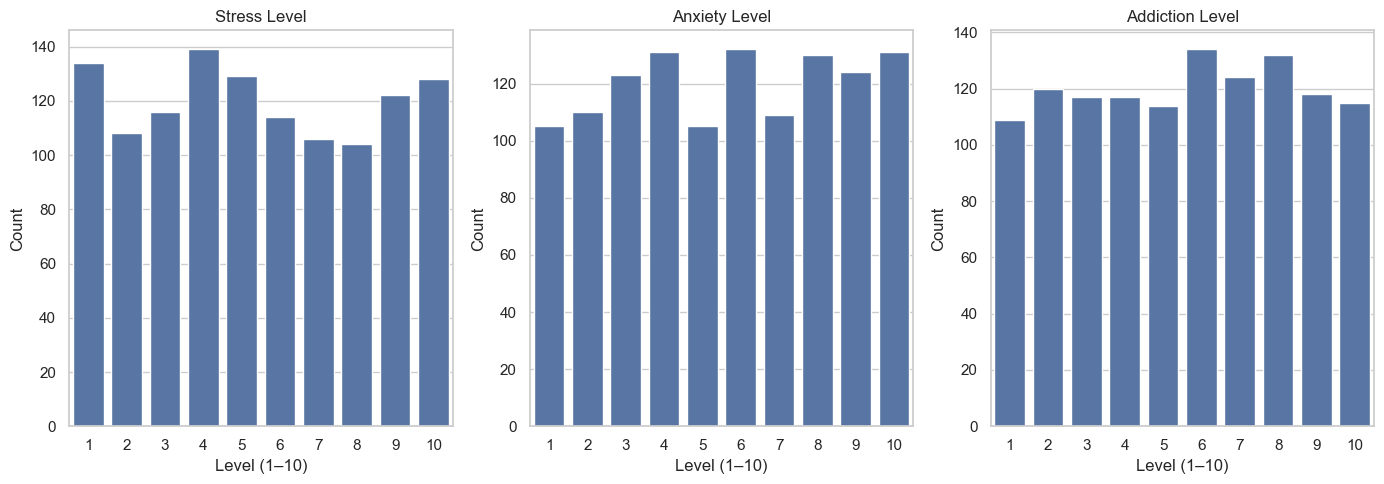

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

columns = ["stress_level", "anxiety_level", "addiction_level"]
titles = ["Stress Level", "Anxiety Level", "Addiction Level"]

for ax, col, title in zip(axes, columns, titles):
    sns.countplot(data=mental_health, x=col, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Level (1–10)")
    ax.set_ylabel("Count")
    ax.set_xticks(range(0, 10))
    ax.set_xticklabels(range(1, 11))

plt.tight_layout()
plt.show()

Die Merkmale `stress_level`, `anxiety_level` und `addiction_level` sind jeweils auf einer Skala von 1 bis 10 erhoben und über die Auaprägung annähernd gleichmäßig verteilt. Es gibt keine ausgeprägt Häufung an den Extremwerten, was auf eine breite Streuung der psychologischen Belastung im Datensatz hindeutet.

#### Kategorische Attribute

##### Gender

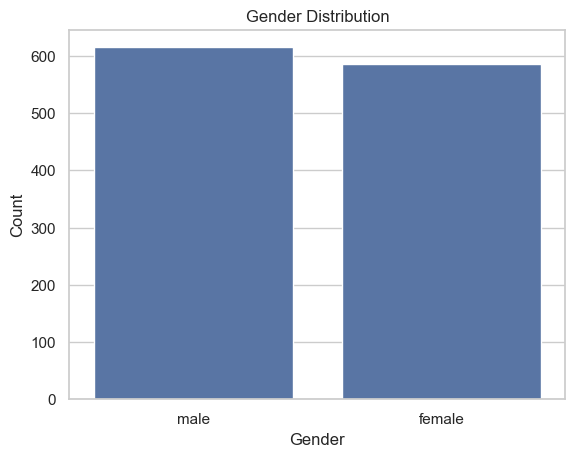

In [30]:
sns.countplot(data=mental_health, x=mental_health["gender"])
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

##### Platform Usage

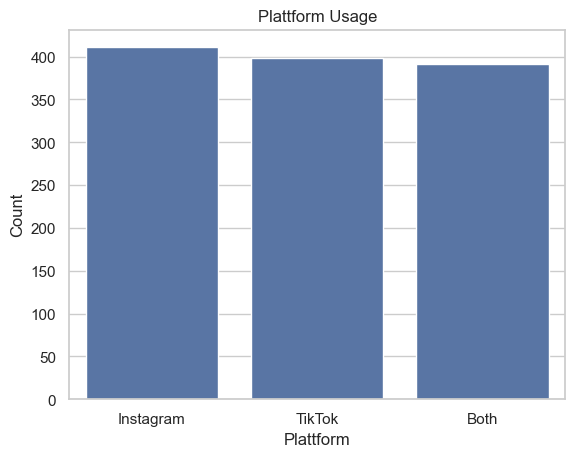

In [31]:
sns.countplot(data=mental_health, x=mental_health["platform_usage"])
plt.title("Plattform Usage")
plt.xlabel("Plattform")
plt.ylabel("Count")
plt.show()

##### Social Interaction Level

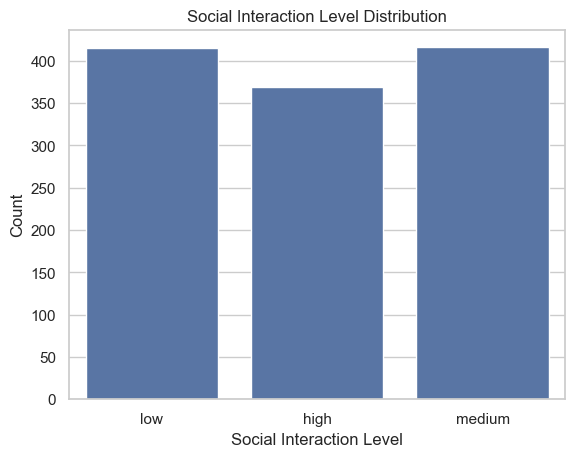

In [32]:
sns.countplot(data=mental_health, x=mental_health["social_interaction_level"])
plt.title("Social Interaction Level Distribution")
plt.xlabel("Social Interaction Level")
plt.ylabel("Count")
plt.show()

### Bivariate Analyse

#### Jedes Merkmal vs Zielvariable

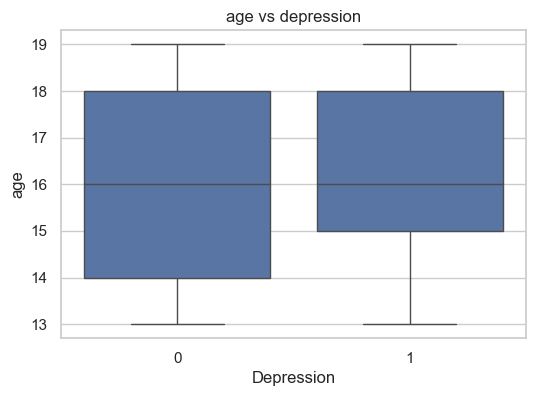

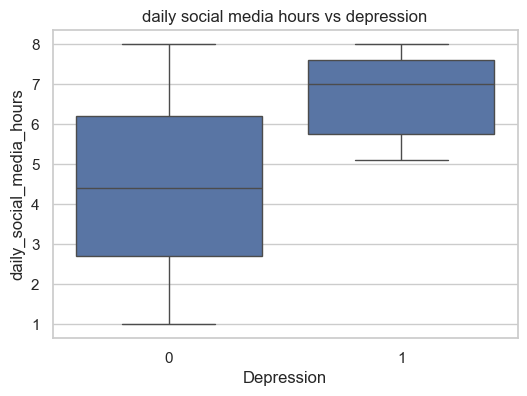

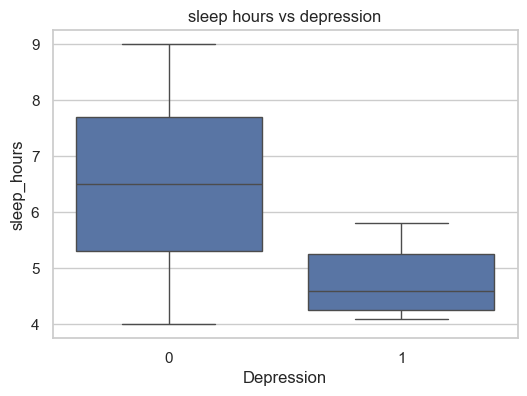

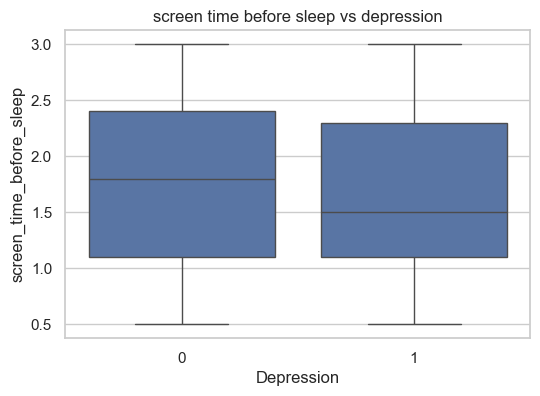

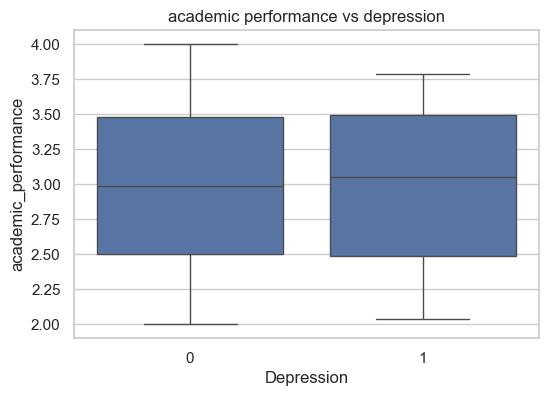

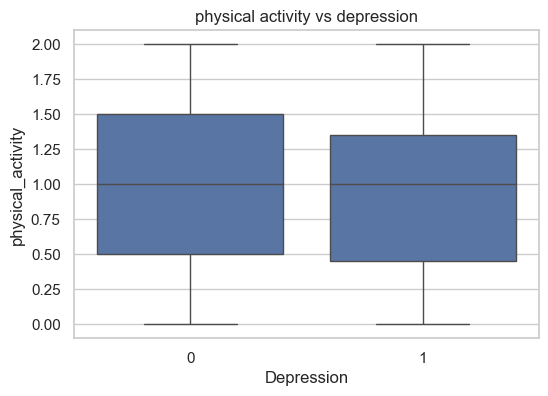

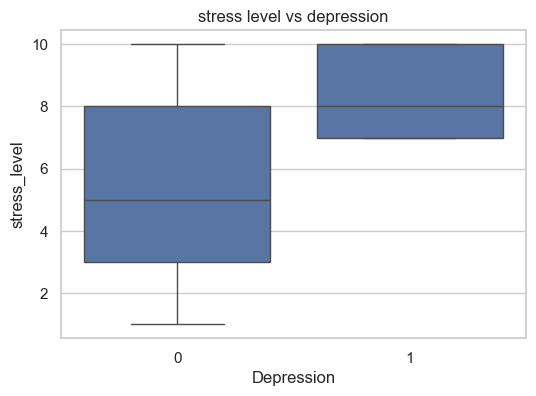

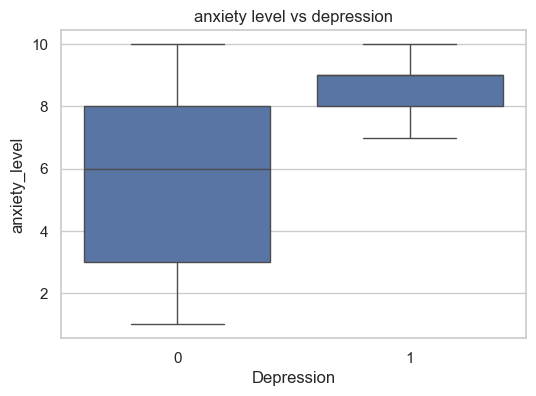

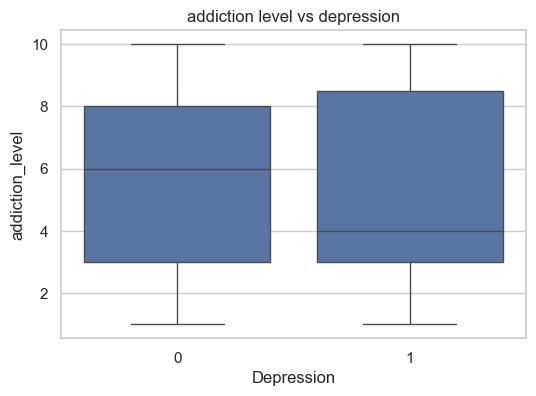

In [33]:
features = ["age", "daily_social_media_hours", "sleep_hours", "screen_time_before_sleep", "academic_performance", "physical_activity", "stress_level", "anxiety_level", "addiction_level"]

for feature in features:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=mental_health, x="depression_label", y=feature)
    plt.title(f"{feature.replace('_',' ')} vs depression")
    plt.xlabel("Depression")
    plt.ylabel(f"{feature}")
    plt.show()
    

Aus den Grafiken lassen sich zwei unterschiedliche Beobachtungen ableiten:

1. `age`, `screen time befor sleep`, `academic performance`, `physicalactivity` und `addiction level` weise eine starke Überlappung der Klassenverteilung auf. Diese Merkmale allein eignen sich kaum zur Unterscheidung zwischen depressiven und nicht-depressiven Jugendlichen.

2. `daily social median hours`, `sleep hours`, `aniety level` und `stress level` zeigen deutlichere Verschiebung zwischen den Klassen. Jugendliche mit Depression weisen tendenziell höhere Social-Media-Nutzung, weniger Schlaf sowie erhöhte Stress- und Angstlevel auf.

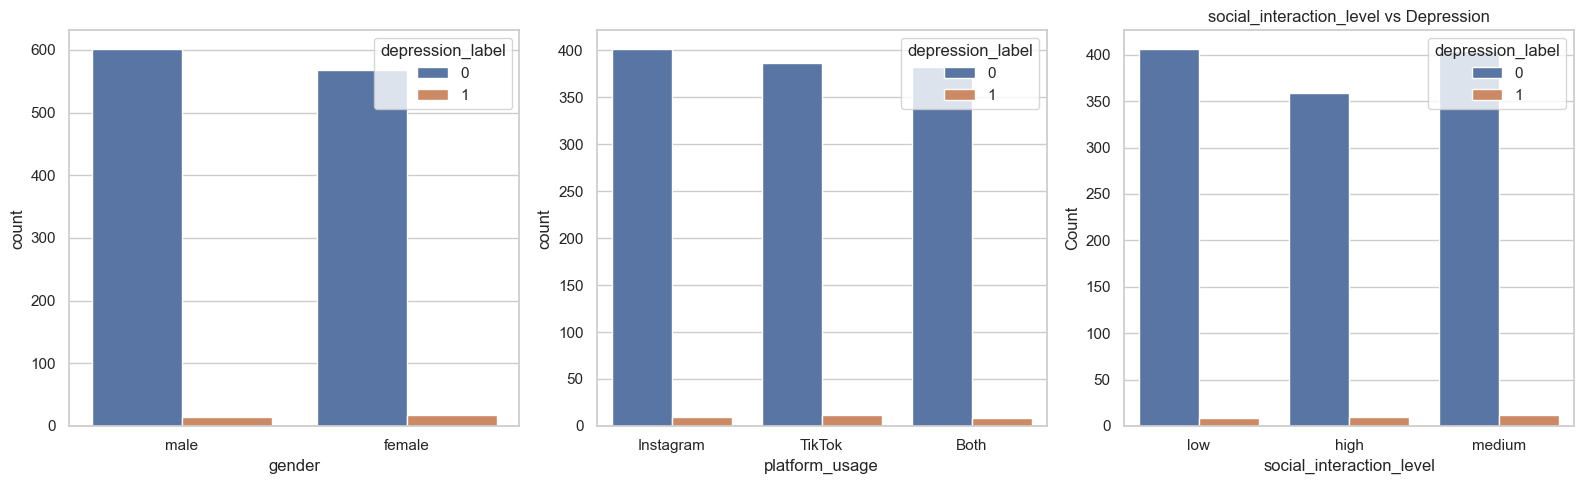

In [34]:
fig ,axes = plt.subplots(1, 3, figsize=(16,5))

features = ["gender", "platform_usage", "social_interaction_level"]

titles = ["Gender", "Platform Usage", "Social Interaction Level"]

for ax, feature, title in zip(axes.flatten(), features, titles):
    sns.countplot(data=mental_health, x=feature, hue="depression_label", ax=ax)
    plt.title(f"{feature} vs Depression")
    plt.xlabel(f"{feature}")
    plt.ylabel("Count")
    
plt.tight_layout()
plt.show()

#### Beziehung zwischen ausgewählten Verhaltens- und Belastungsmerkalen

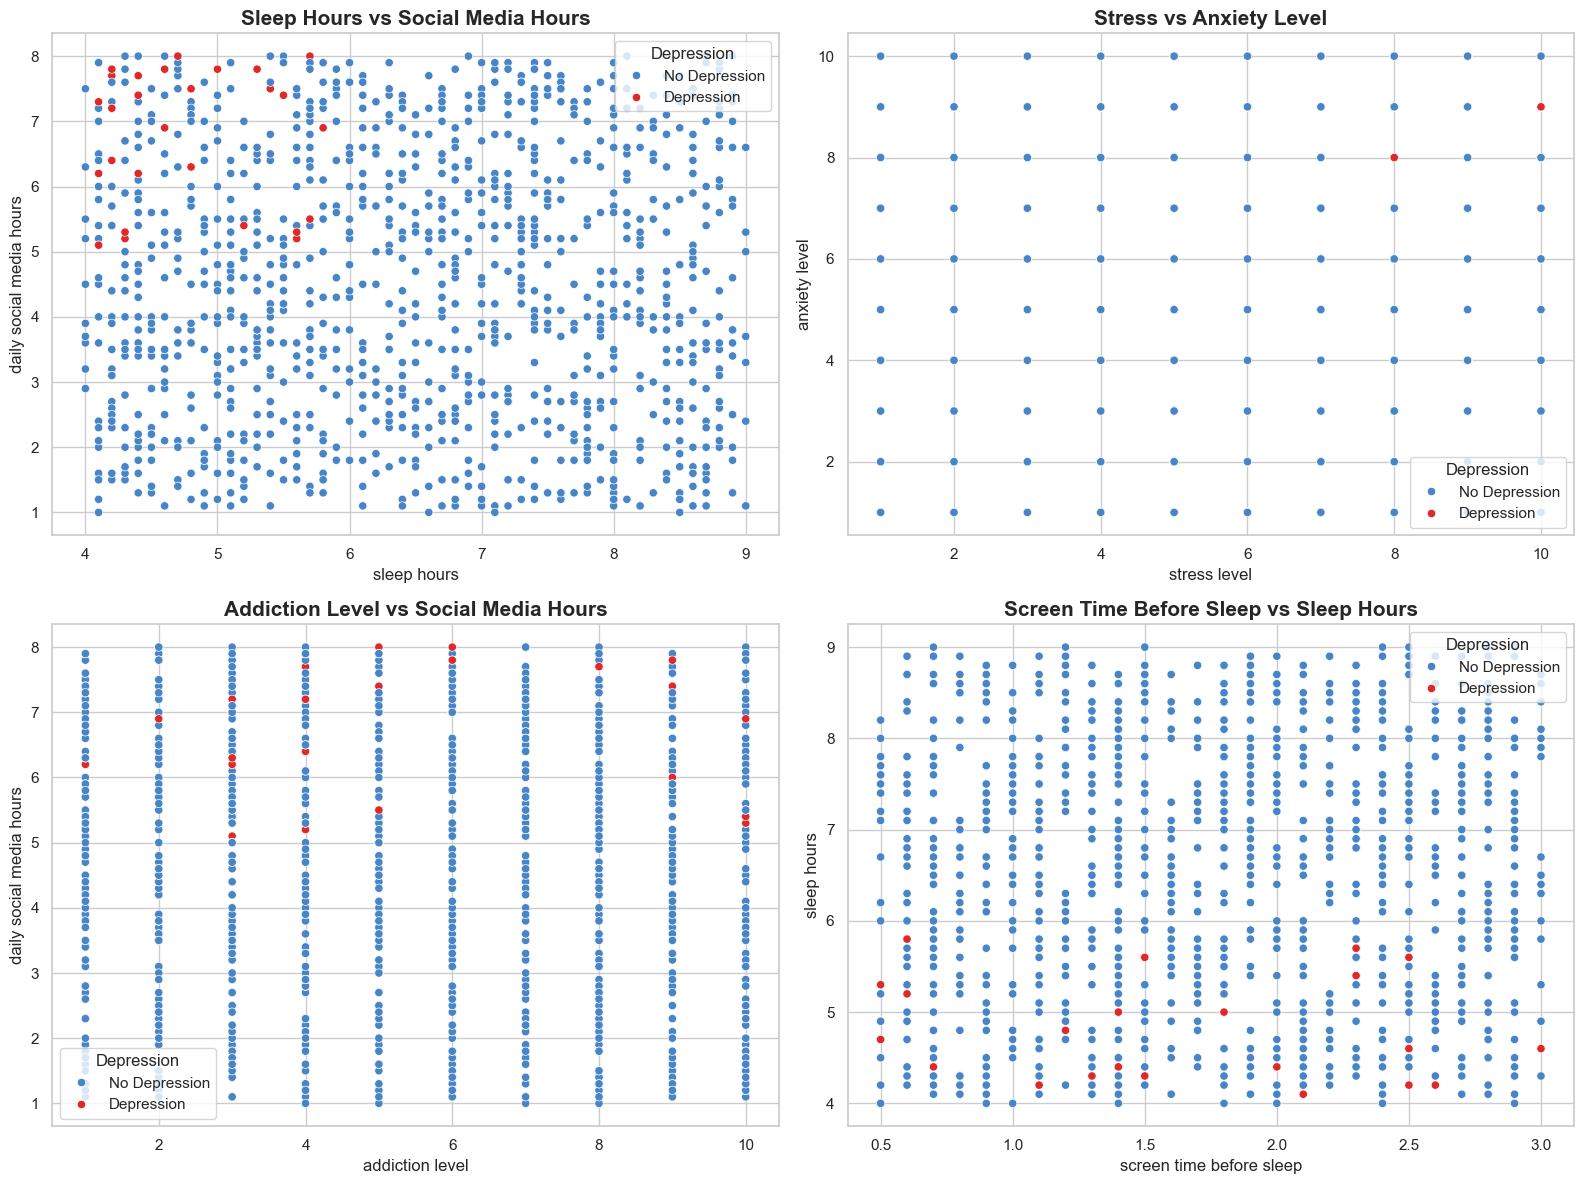

In [35]:
fig ,axes = plt.subplots(2, 2, figsize=(16,12))

features_x = ["sleep_hours", "stress_level", "addiction_level", "screen_time_before_sleep"]


features_y = ["daily_social_media_hours", "anxiety_level", "daily_social_media_hours", "sleep_hours"]

titles = ["Sleep Hours vs Social Media Hours", "Stress vs Anxiety Level",
          "Addiction Level vs Social Media Hours", "Screen Time Before Sleep vs Sleep Hours"]

palette = {0: "#4785C7", 1: "#DF2828"} 

for ax, feature_x, feature_y, title in zip(axes.flatten(), features_x, features_y, titles):
    sns.scatterplot(data=mental_health, x=feature_x, y=feature_y, hue="depression_label", ax=ax, palette=palette)
    ax.set_title(title, fontsize=15, fontweight="bold")
    ax.set_xlabel(feature_x.replace("_"," "))
    ax.set_ylabel(feature_y.replace("_"," "))
    handles, _ = ax.get_legend_handles_labels()
    ax.legend(handles=handles,title="Depression", labels=["No Depression", "Depression"])
    
plt.tight_layout()
plt.show()

Die Scatter-Plots bestätigen die Befunde aus der Boxplot-Analyse. Besonders auffällig ist der Zusamnmenhang zwischen höherer Social-Media-nutzung und weniger Schlaf bei depressiven Jugendlichen. Zudem zeigt sich, dass erhöhte Stress- und Angstwerte häufig gemeinsam auftreten. der Zusammenhang zwischen `screen_time_befor_sleep` und `sleep_hours` ist dagegen weniger eindeutig, die Klassen überlappen stark, was keinen klaren linearen Einfluss der Bildschirmzeit auf die Schlafdauer erkennen lässt.

### Multivariate Analyse

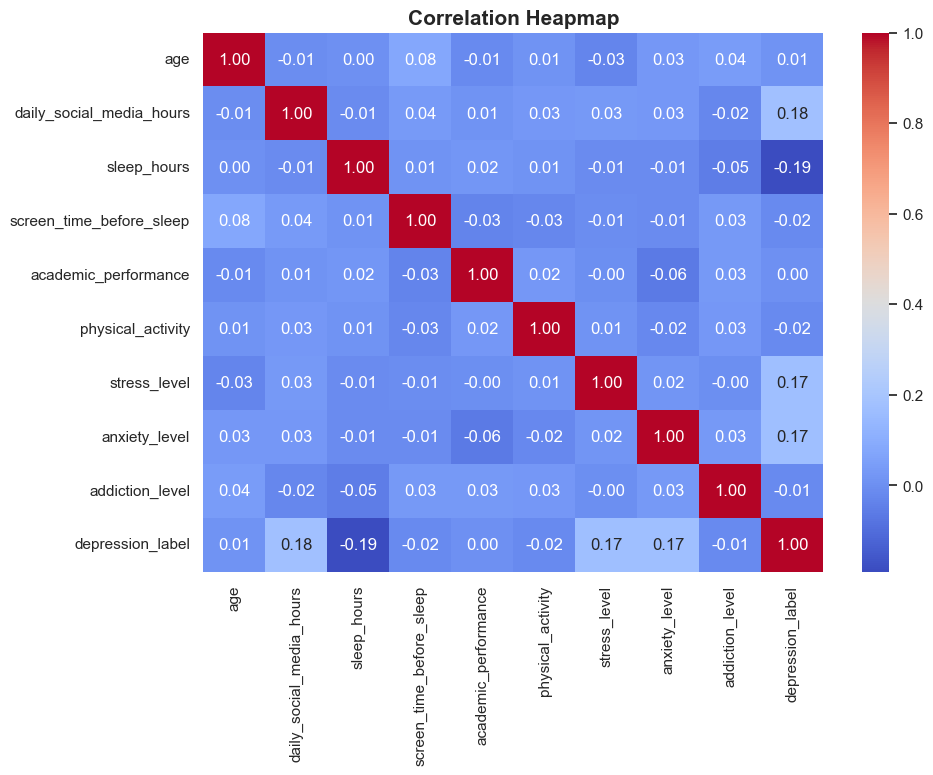

In [36]:
plt.figure(figsize=(10,7))
sns.heatmap(
    mental_health.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heapmap", fontsize=15, fontweight="bold")
plt.show()

Wie bereits in der bivarianten Analysis festgestellt, weisen die Merkmale `daily_social_hours`, `sleep_hours`, `stress_level`, `anxienty_level` vergeleichsweise höhere Korrelationswerte mit der Zielvariable auf. Dies deutet auf einen stärkeren Zusammenhang mit dem Auftreten von Depressionen hin.

<Figure size 1800x1200 with 0 Axes>

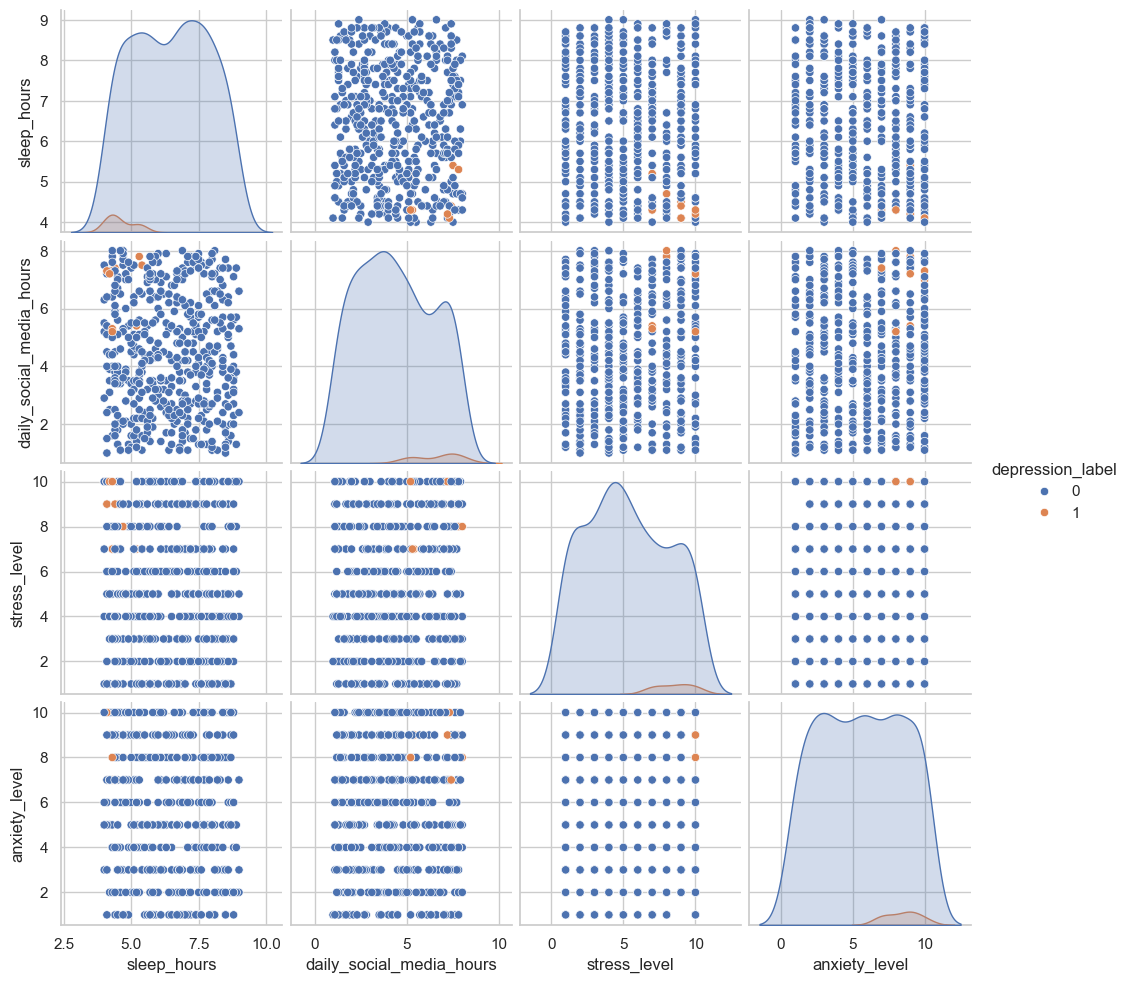

In [37]:
sample_df = mental_health.sample(500, random_state=42)

plt.figure(figsize=(18,12))

sns.pairplot(
    sample_df,
    vars=["sleep_hours", "daily_social_media_hours", "stress_level", "anxiety_level"],
    hue="depression_label"
)

plt.show()

Der Pairplot visualisiert die Beziehung zwischen den vier trennschärfsten Merkmale. Es zeigt sich eine tendenzielle Separation der Klassen, insbesondere entlang der Achsen `stress_level` und `anxiety_level`. Eine vollständige Trennbarkeit ist jedoch nicht gegeben, denn die Klassen überlappen.